In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile
import os

# Extract the ZIP file
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Show extracted files
print("=== Extracted Files ===")
print(os.listdir('.'))

=== Extracted Files ===
['.config', 'Assignment-1_Data.csv', 'Assignment-1_Data.xlsx', 'archive (1).zip', 'sample_data']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel file instead
df = pd.read_excel('Assignment-1_Data.xlsx')

print("=== First 5 Rows ===")
print(df.head())

print("\n=== Shape ===")
print(df.shape)

print("\n=== Columns ===")
print(df.columns.tolist())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n✅ Data Loaded Successfully!")

=== First 5 Rows ===
   BillNo                             Itemname  Quantity                Date  \
0  536365   WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00   
1  536365                  WHITE METAL LANTERN         6 2010-12-01 08:26:00   
2  536365       CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00   
3  536365  KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00   
4  536365       RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-01 08:26:00   

   Price  CustomerID         Country  
0   2.55     17850.0  United Kingdom  
1   3.39     17850.0  United Kingdom  
2   2.75     17850.0  United Kingdom  
3   3.39     17850.0  United Kingdom  
4   3.39     17850.0  United Kingdom  

=== Shape ===
(522064, 7)

=== Columns ===
['BillNo', 'Itemname', 'Quantity', 'Date', 'Price', 'CustomerID', 'Country']

=== Missing Values ===
BillNo             0
Itemname        1455
Quantity           0
Date               0
Price              0
CustomerID    

In [6]:
# DATA CLEANING

# 1. Remove Duplicates
print("=== Before Cleaning ===")
print(f"Total Rows: {len(df)}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
print(f"\nAfter Removing Duplicates: {len(df)} rows")

# 2. Handle Missing Values
print("\n=== Missing Values Before ===")
print(df.isnull().sum())

df.fillna("Unknown", inplace=True)

print("\n=== Missing Values After ===")
print(df.isnull().sum())

# 3. Strip extra spaces from text columns
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 4. Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("\n=== Cleaned Column Names ===")
print(df.columns.tolist())

print("\n✅ Data Cleaning Done!")

=== Before Cleaning ===
Total Rows: 522064
Duplicate Rows: 5286

After Removing Duplicates: 516778 rows

=== Missing Values Before ===
BillNo             0
Itemname        1455
Quantity           0
Date               0
Price              0
CustomerID    133967
Country            0
dtype: int64


/tmp/ipykernel_8127/3550325443.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)



=== Missing Values After ===
BillNo        0
Itemname      0
Quantity      0
Date          0
Price         0
CustomerID    0
Country       0
dtype: int64


/tmp/ipykernel_8127/3550325443.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)



=== Cleaned Column Names ===
['billno', 'itemname', 'quantity', 'date', 'price', 'customerid', 'country']

✅ Data Cleaning Done!


=== Numeric Columns ===
['quantity', 'price']


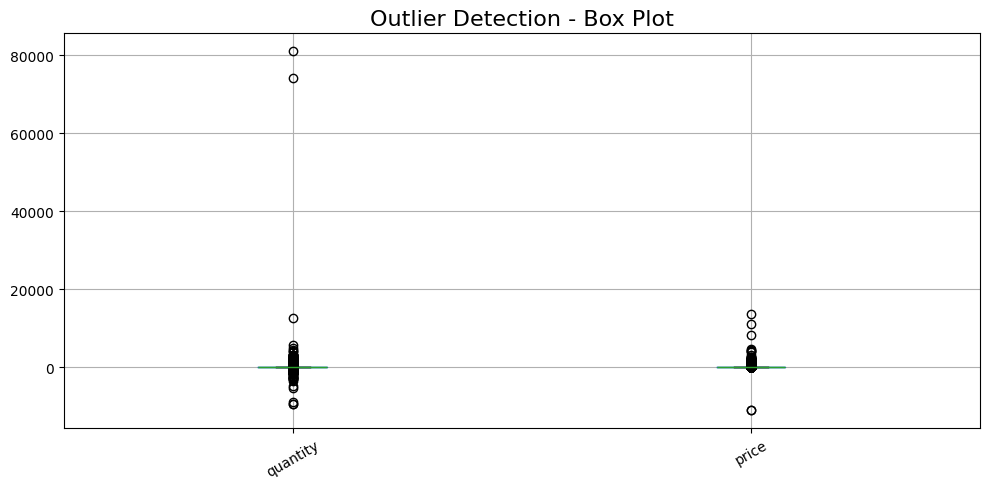

✅ Outlier Detection Done!


In [7]:
# OUTLIER DETECTION
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=== Numeric Columns ===")
print(numeric_cols)

# Box plot for outliers
if len(numeric_cols) > 0:
    plt.figure(figsize=(10, 5))
    df[numeric_cols].boxplot()
    plt.title('Outlier Detection - Box Plot', fontsize=16)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    print("✅ Outlier Detection Done!")
else:
    print("No numeric columns found!")

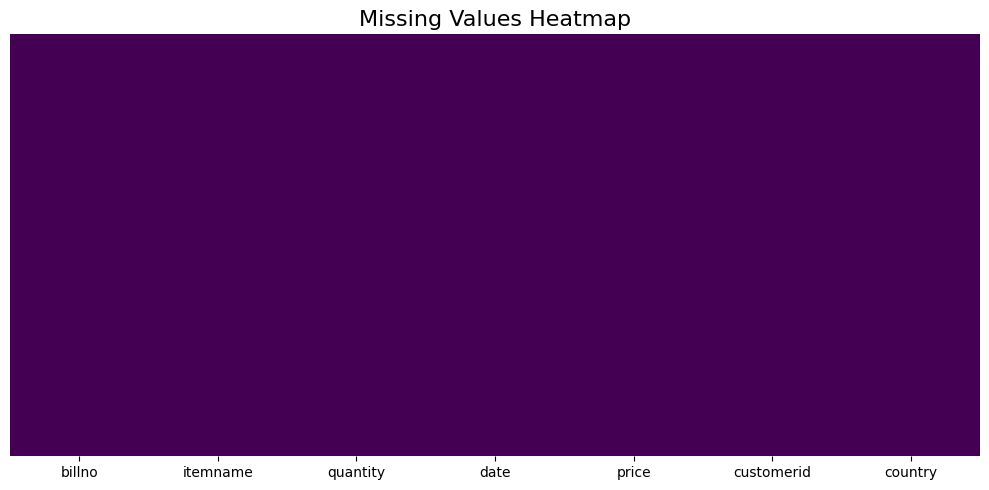

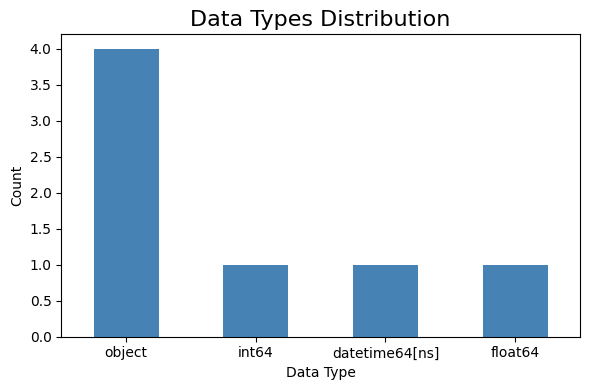

✅ Visualization Done!


In [8]:
# DATA VISUALIZATION

# 1. Missing values heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False,
            cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Data types count
plt.figure(figsize=(6, 4))
df.dtypes.value_counts().plot(kind='bar',
                               color='steelblue')
plt.title('Data Types Distribution', fontsize=16)
plt.xlabel('Data Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ Visualization Done!")

In [9]:
# SUMMARY & CONCLUSIONS

print("=== FINAL CLEANED DATASET ===")
print(f"Total Rows    : {len(df)}")
print(f"Total Columns : {len(df.columns)}")

print("\n=== DATA CLEANING SUMMARY ===")
print("1. Removed duplicate records ✅")
print("2. Handled missing values ✅")
print("3. Stripped extra spaces ✅")
print("4. Standardized column names ✅")
print("5. Detected outliers ✅")

print("\n=== CONCLUSIONS ===")
print("1. Data is now clean and ready for analysis")
print("2. Missing values replaced with 'Unknown'")
print("3. Outliers identified through box plots")
print("4. Consistent formatting applied throughout")

print("\n✅ Project 2 - Data Cleaning COMPLETE! ")

=== FINAL CLEANED DATASET ===
Total Rows    : 516778
Total Columns : 7

=== DATA CLEANING SUMMARY ===
1. Removed duplicate records ✅
2. Handled missing values ✅
3. Stripped extra spaces ✅
4. Standardized column names ✅
5. Detected outliers ✅

=== CONCLUSIONS ===
1. Data is now clean and ready for analysis
2. Missing values replaced with 'Unknown'
3. Outliers identified through box plots
4. Consistent formatting applied throughout

✅ Project 2 - Data Cleaning COMPLETE! 
